### Importing

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from scipy.stats import uniform , randint
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "Car.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### EDA

In [56]:
df.shape

(301, 9)

In [57]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [58]:
df.duplicated().sum()

np.int64(2)

In [59]:
df = df.drop_duplicates()

In [60]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Kms_Driven     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Seller_Type    299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 23.4+ KB


In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,299.0,2013.615385,2.896868,2003.00,2012.00,2014.00,2016.00,2018.0
Selling_Price,299.0,4.589632,4.984240,0.10,0.85,3.51,6.00,35.0
Present_Price,299.0,7.541037,8.567887,0.32,1.20,6.10,9.84,92.6
Kms_Driven,299.0,36916.752508,39015.170352,500.00,15000.00,32000.00,48883.50,500000.0
Owner,299.0,0.043478,0.248720,0.00,0.00,0.00,0.00,3.0


In [63]:
df.describe(include = ["object"]).T

,count,unique,top,freq
Car_Name,299,98,city,26
Fuel_Type,299,3,Petrol,239
Seller_Type,299,2,Dealer,193
Transmission,299,2,Manual,260


In [64]:
df = df.drop(columns = ["Car_Name"])

In [65]:
df.insert(loc = 0 , column = "Age" , value = 2025 - df["Year"])
df = df.drop(columns = ["Year"])

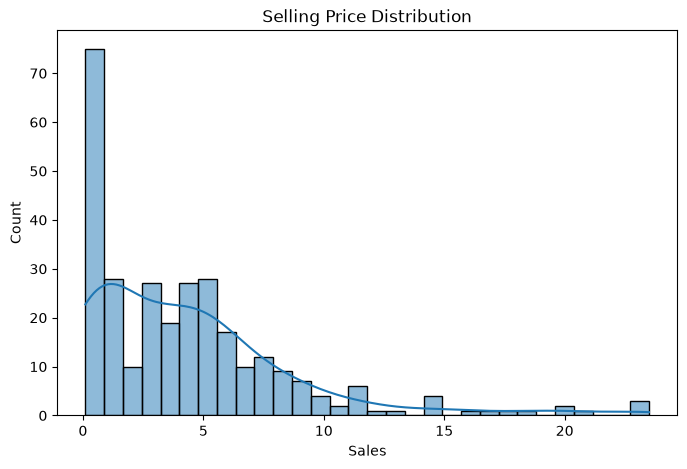

In [69]:
plt.figure(figsize = (8 , 5))
sns.histplot(df["Selling_Price"] , bins = 30 , kde = True)

plt.title("Selling Price Distribution")
plt.xlabel("Sales")
plt.ylabel("Count")
plt.show()

In [68]:
df = df.drop(index = df[df["Selling_Price"] > 30].index)

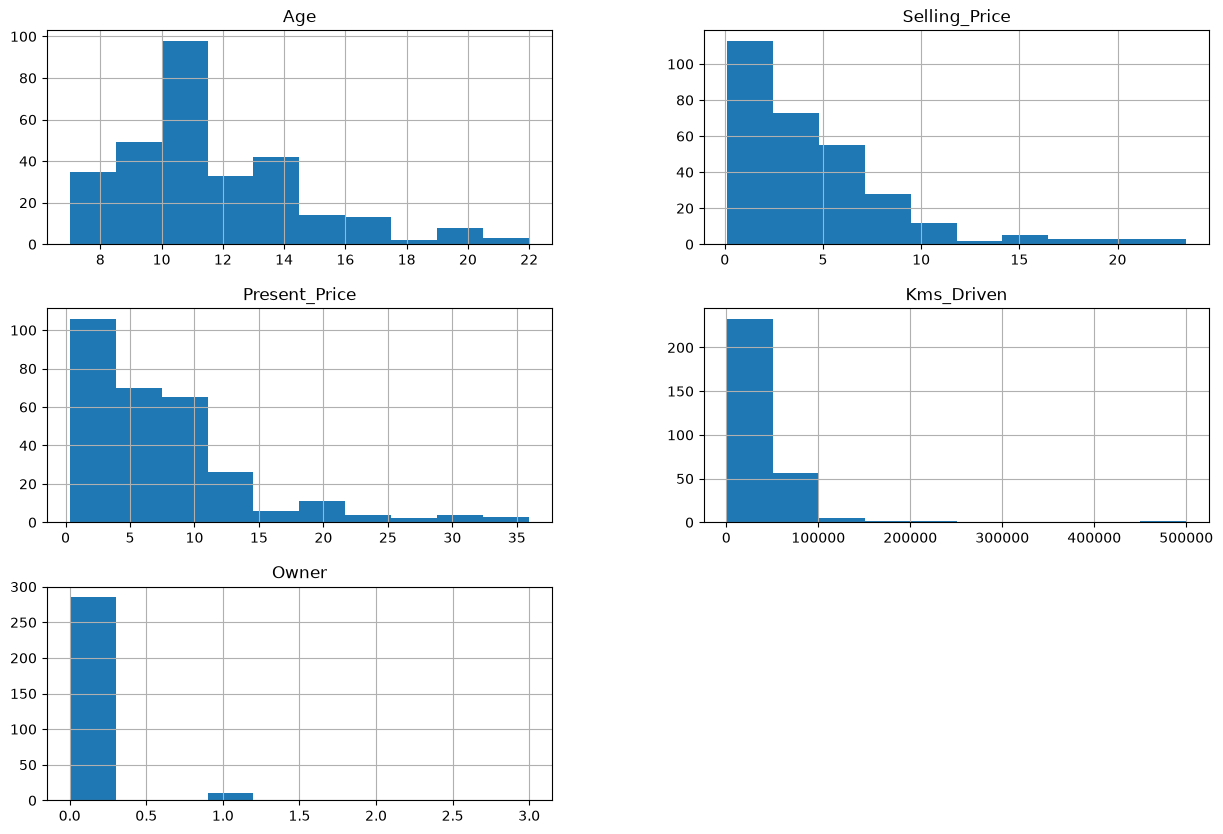

In [70]:
df.hist(figsize = (15 , 10))
plt.show()

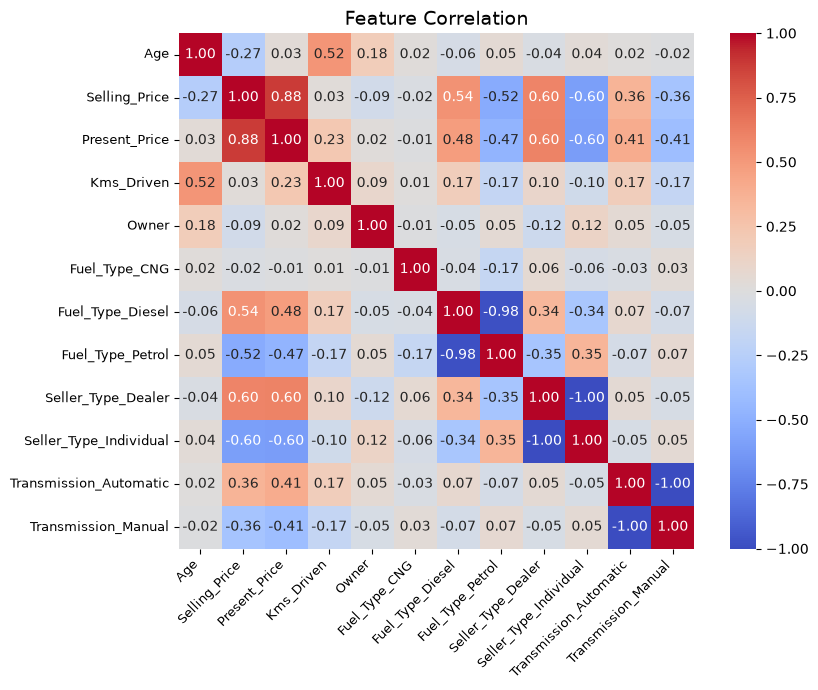

In [71]:
plt.figure(figsize = (9 , 7))
sns.heatmap(pd.get_dummies(df).corr() , annot = True , fmt = ".2f" , square = True , cmap = "coolwarm")

plt.title("Feature Correlation" , fontsize = 14)
plt.xticks(rotation = 45 , ha = "right" , fontsize = 9)
plt.yticks(rotation = 0 , fontsize = 9)
plt.tight_layout()
plt.show()

### Preprocessing Data

In [72]:
le = LabelEncoder()
df["Seller_Type"] = le.fit_transform(df["Seller_Type"].astype(str))
df["Transmission"] = le.fit_transform(df["Transmission"].astype(str))

In [73]:
target = df["Selling_Price"]

In [74]:
df = pd.get_dummies(df.drop(columns = ["Selling_Price"]) , drop_first = False , dtype = int)

### Feature & Target Split

In [75]:
X = df
y = target

### Train & Test Split

In [76]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 101)

### RandomizedSearchCV & Model Training

In [77]:
xgb_model = XGBRegressor(objective = "reg:squarederror")

In [78]:
param_distributions = {
    "n_estimators" : randint(100 , 150) , 
    "gamma" : uniform(0 , 0.05) ,
    "learning_rate" : uniform(0.03 , 0.3) ,
    "max_depth" : randint(2 , 6) , 
    "subsample" : uniform(0.4 , 0.6)
}

In [79]:
rf_model = RandomizedSearchCV(estimator = xgb_model , param_distributions = param_distributions , 
                              scoring = "neg_mean_squared_error" , n_iter = 10 , cv = 5 , 
                              n_jobs = 1 , random_state = 101)
rf_model.fit(X_train , y_train)
rf_model.best_params_

{'gamma': np.float64(0.03657547753794251),
 'learning_rate': np.float64(0.2779075889466408),
 'max_depth': 3,
 'n_estimators': 118,
 'subsample': np.float64(0.6143346056924728)}

### Prediction

In [80]:
y_pred = rf_model.predict(X_test)

### Evaluation

In [81]:
print("Final Model : XGBoost Regressor")
print(f"MAE : {mean_absolute_error(y_test , y_pred)}")
print(f"MSE : {mean_squared_error(y_test , y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test , y_pred)}")
print(f"R2 Score : {r2_score(y_test , y_pred)}")

Final Model : XGBoost Regressor
MAE : 0.42308783196409544
MSE : 0.4935473457420751
RMSE : 0.7025292490295867
R2 Score : 0.9580867341981223


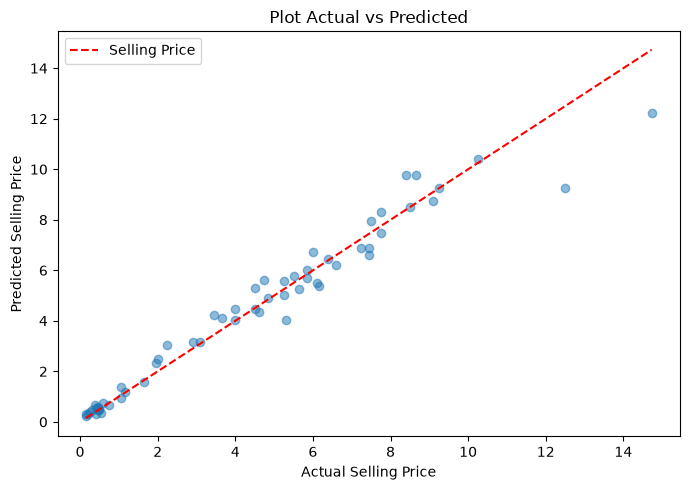

In [82]:
plt.figure(figsize = (7 , 5))
plt.scatter(y_test , y_pred , alpha = 0.5)
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , color = "red" , linestyle = "--" , label = "Selling Price")

plt.title("Plot Actual vs Predicted")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.tight_layout()
plt.legend()
plt.show()

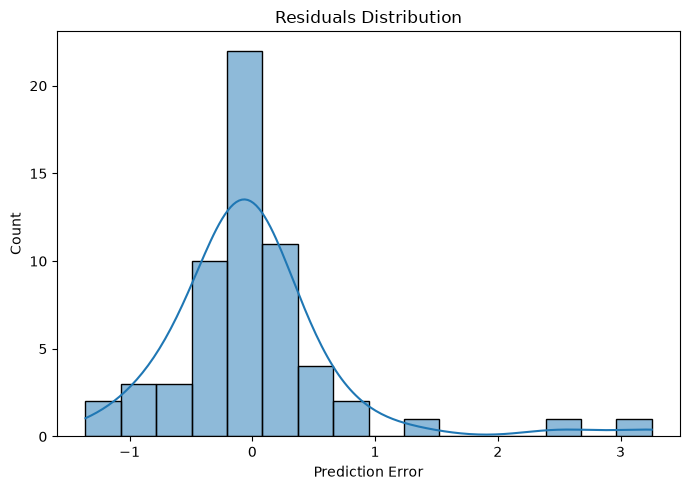

In [83]:
residuals = y_test - y_pred

plt.figure(figsize = (7 , 5))
sns.histplot(residuals , kde = True)

plt.title("Residuals Distribution")
plt.xlabel("Prediction Error")
plt.tight_layout()
plt.show()